# Baseline models: XGB and local-trend-predictor

I've mainly been working on Influenza, though norovirus is supposed to also be an interesting one for this task.

In [1]:
!hpc-ticket
!hpc-mount wissdaten

In [2]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


(<Figure size 2200x600 with 2 Axes>, <Axes: title={'center': 'node: 1'}>)

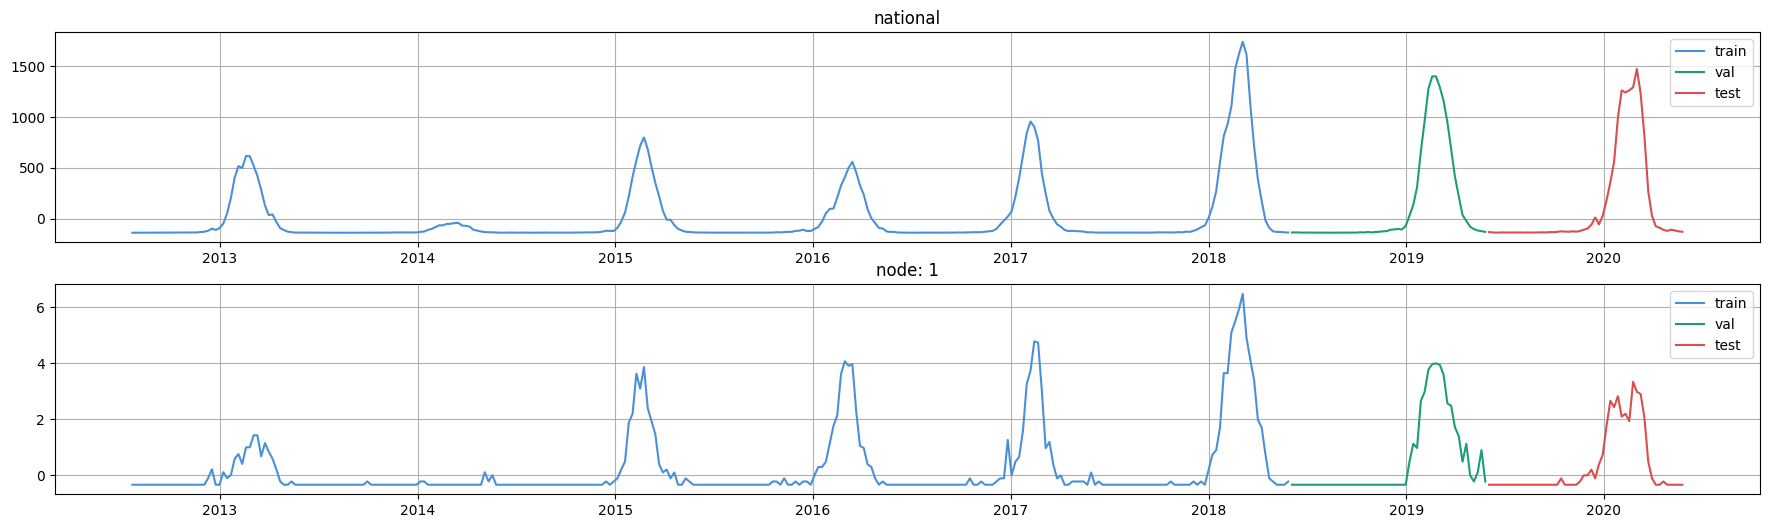

In [3]:
epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(1,8))
epidata.preview()

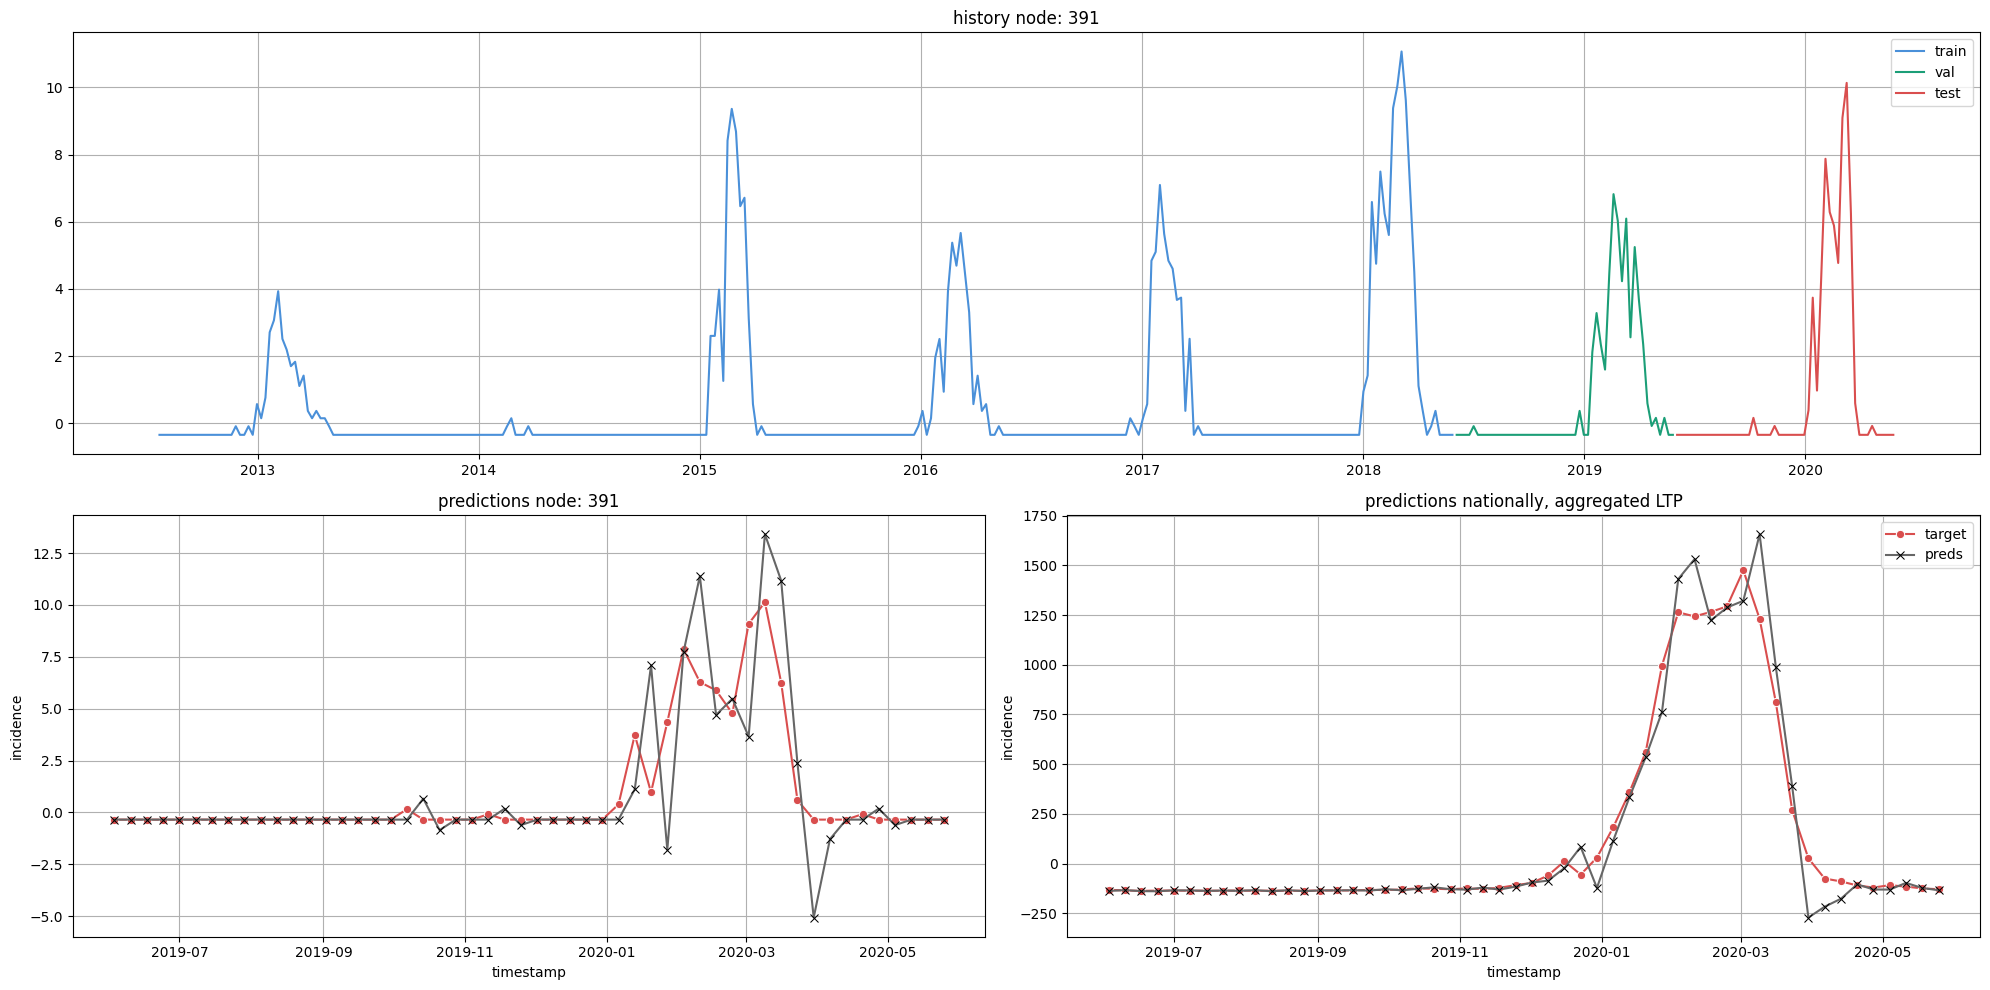

In [5]:
from src.models.localtrendpredictor import LocalTrendPredictor

dataloader_copy = epidata

ltp = LocalTrendPredictor(dataloader_copy)
ltp.forecast()
ltp.show_forecasts(391)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[0]	train-rmse:0.96710	val-rmse:1.31980
[20]	train-rmse:0.48909	val-rmse:0.65056
[40]	train-rmse:0.37421	val-rmse:0.47675
[60]	train-rmse:0.34944	val-rmse:0.43876
[80]	train-rmse:0.34109	val-rmse:0.42963
[100]	train-rmse:0.33614	val-rmse:0.42750
[116]	train-rmse:0.33292	val-rmse:0.42765


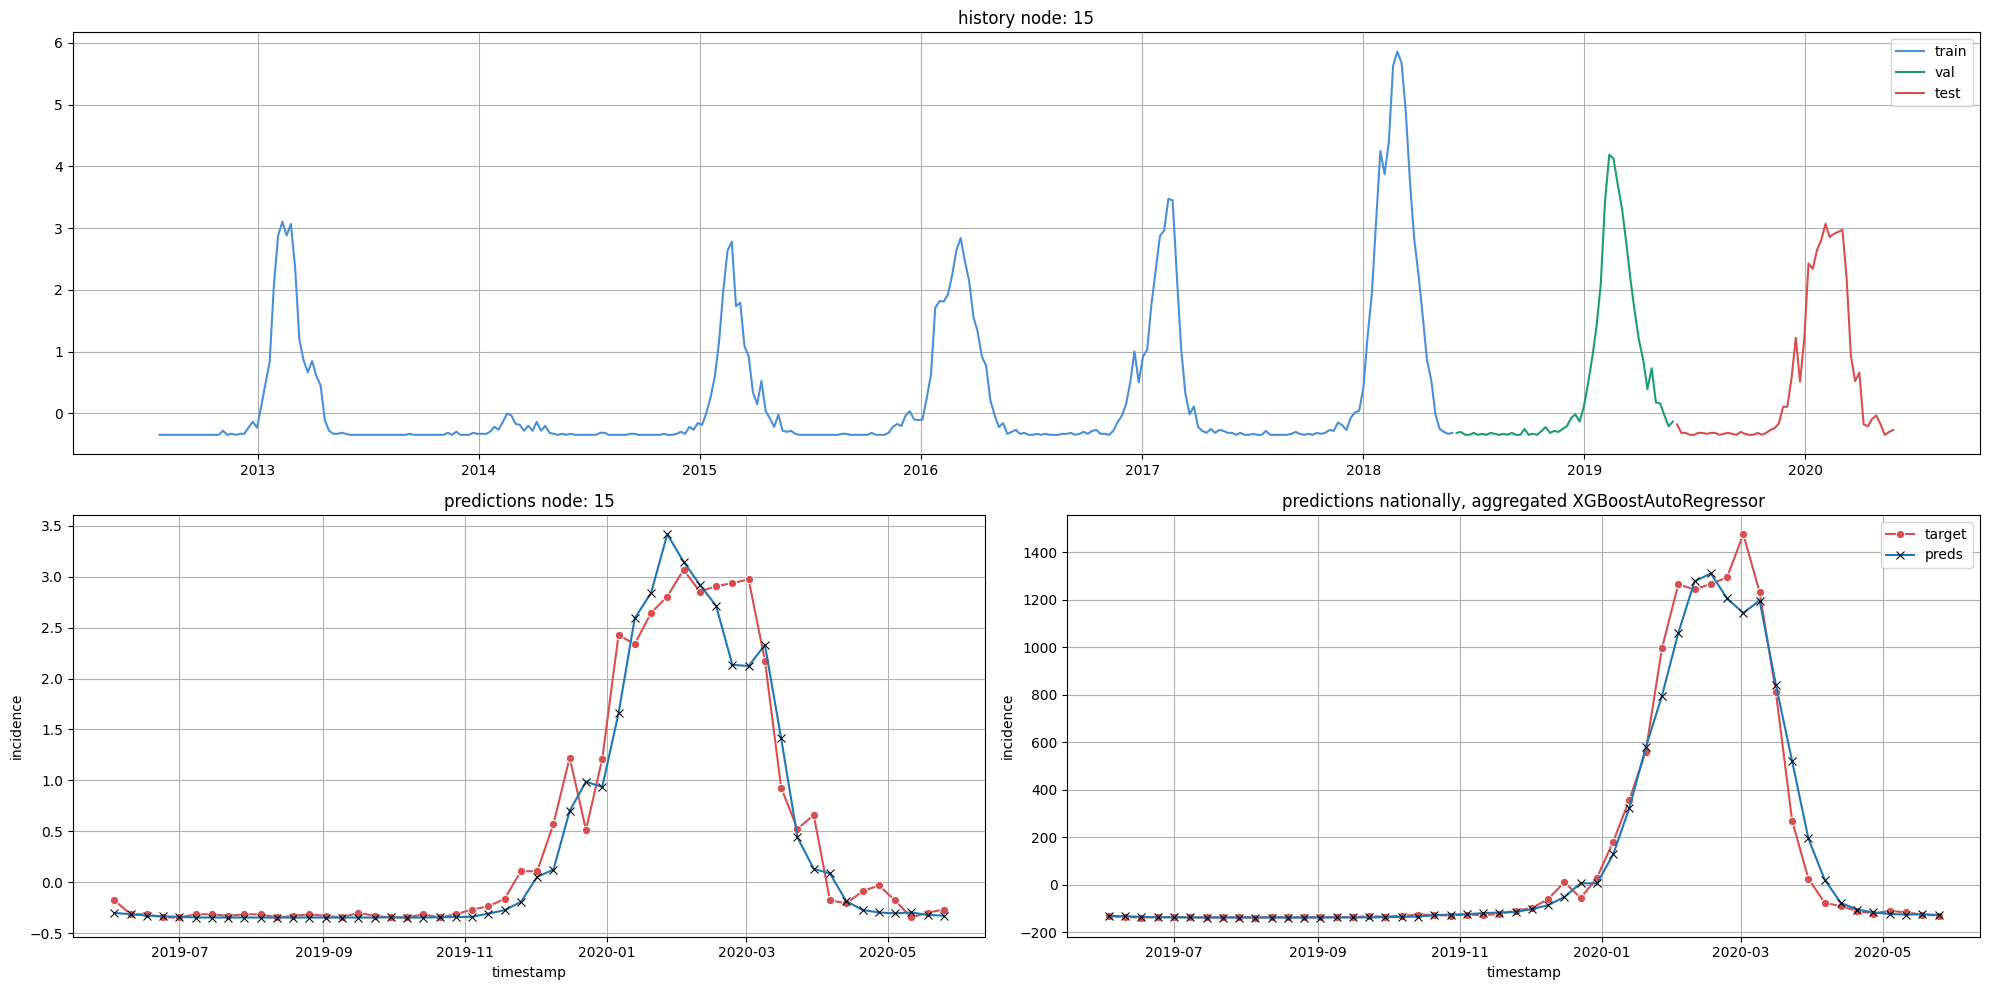

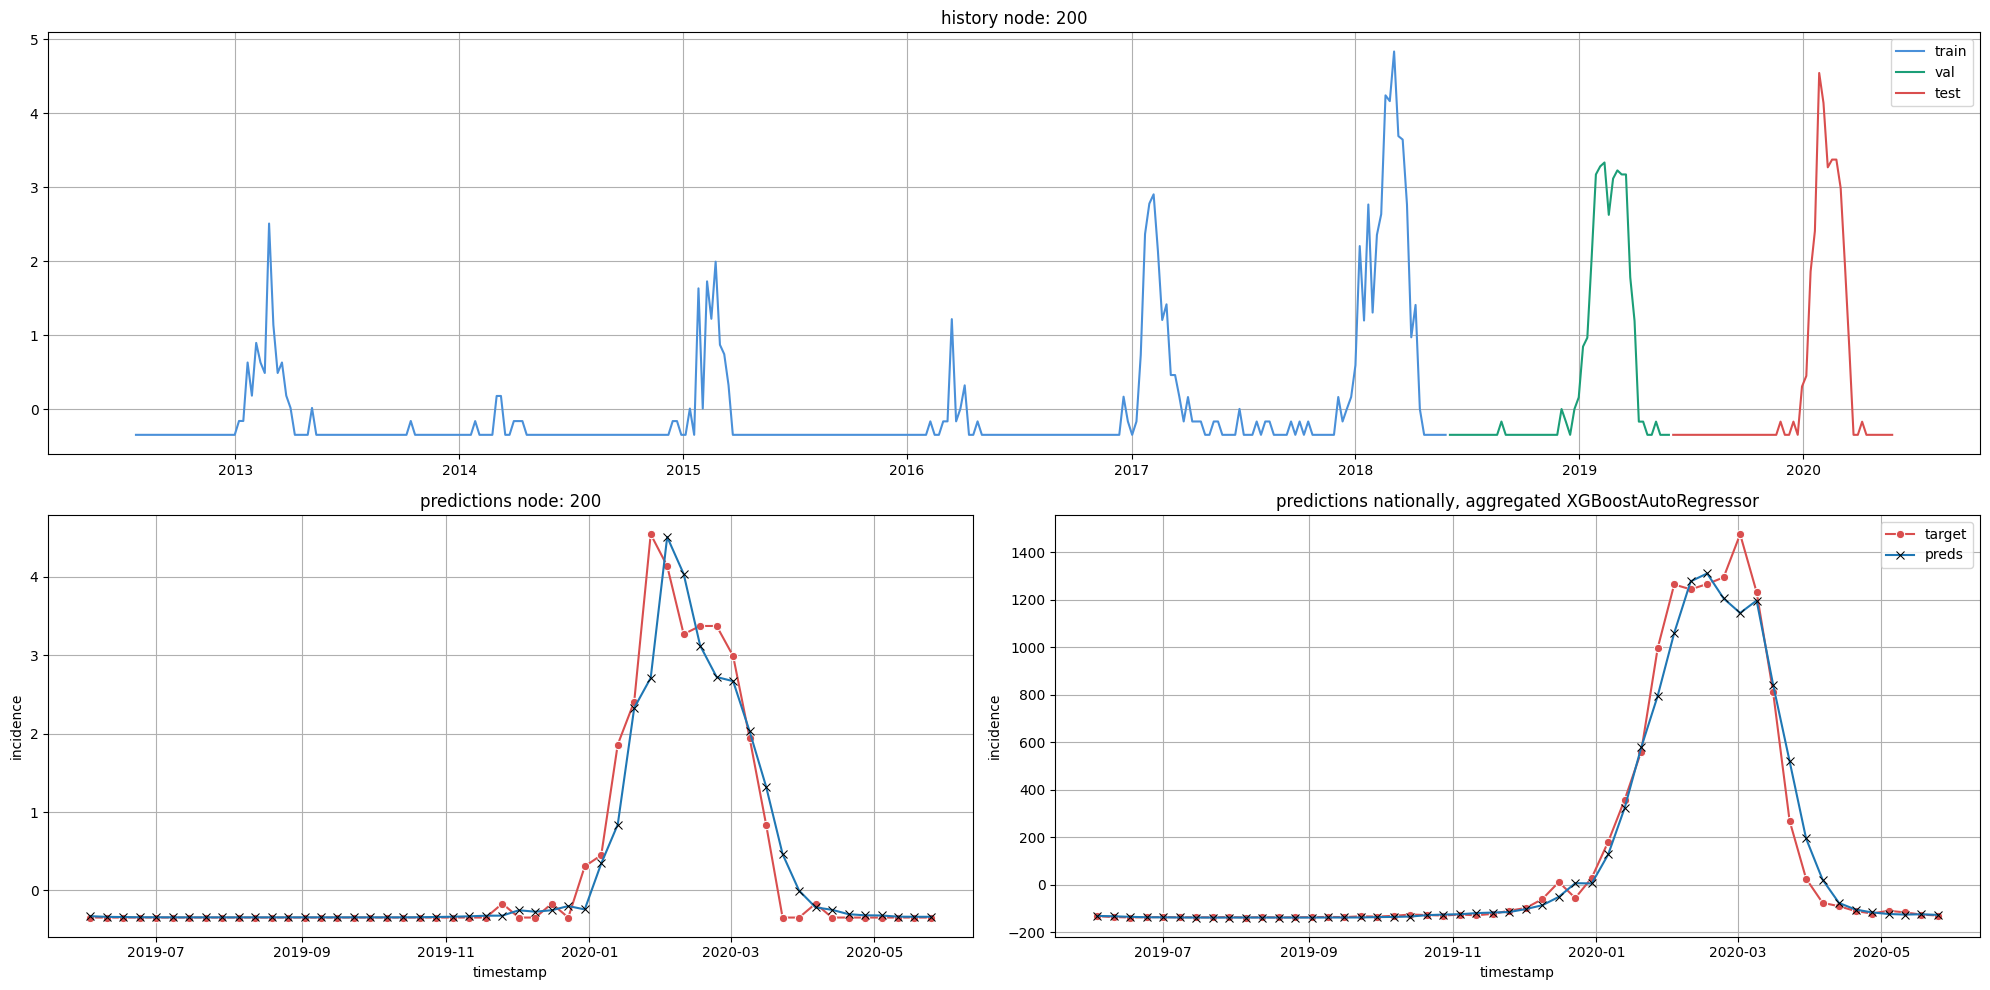

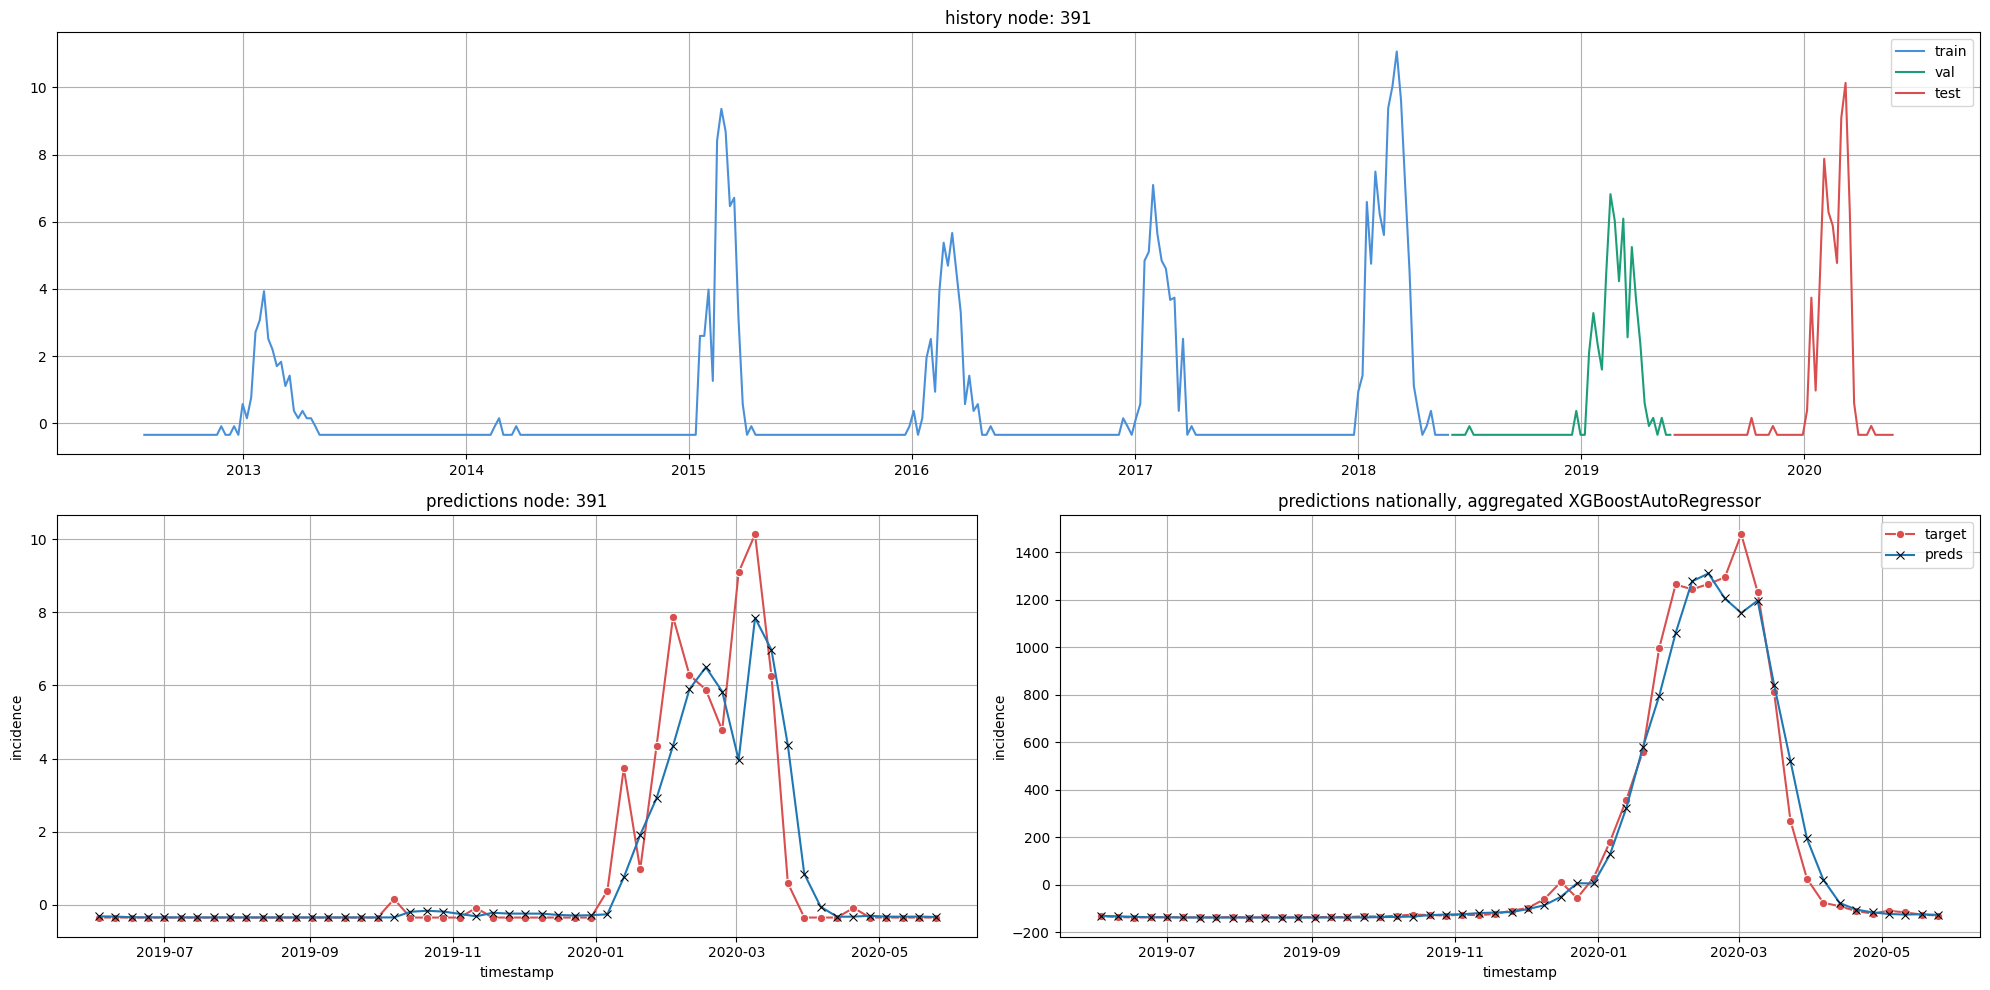

In [8]:
from src.models import XGBoostAutoRegressor
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader

xgb_model = XGBoostAutoRegressor(epidata)
xgb_model.forecast()
xgb_model.show_forecasts(15)
xgb_model.show_forecasts(200)
xgb_model.show_forecasts(391)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


[0]	train-rmse:0.97811	val-rmse:1.33684
[20]	train-rmse:0.66567	val-rmse:0.87624
[40]	train-rmse:0.58505	val-rmse:0.72359
[60]	train-rmse:0.55913	val-rmse:0.66657
[80]	train-rmse:0.54818	val-rmse:0.65006
[100]	train-rmse:0.54068	val-rmse:0.64244
[120]	train-rmse:0.53444	val-rmse:0.64182
[140]	train-rmse:0.52909	val-rmse:0.64184
[153]	train-rmse:0.52601	val-rmse:0.64219


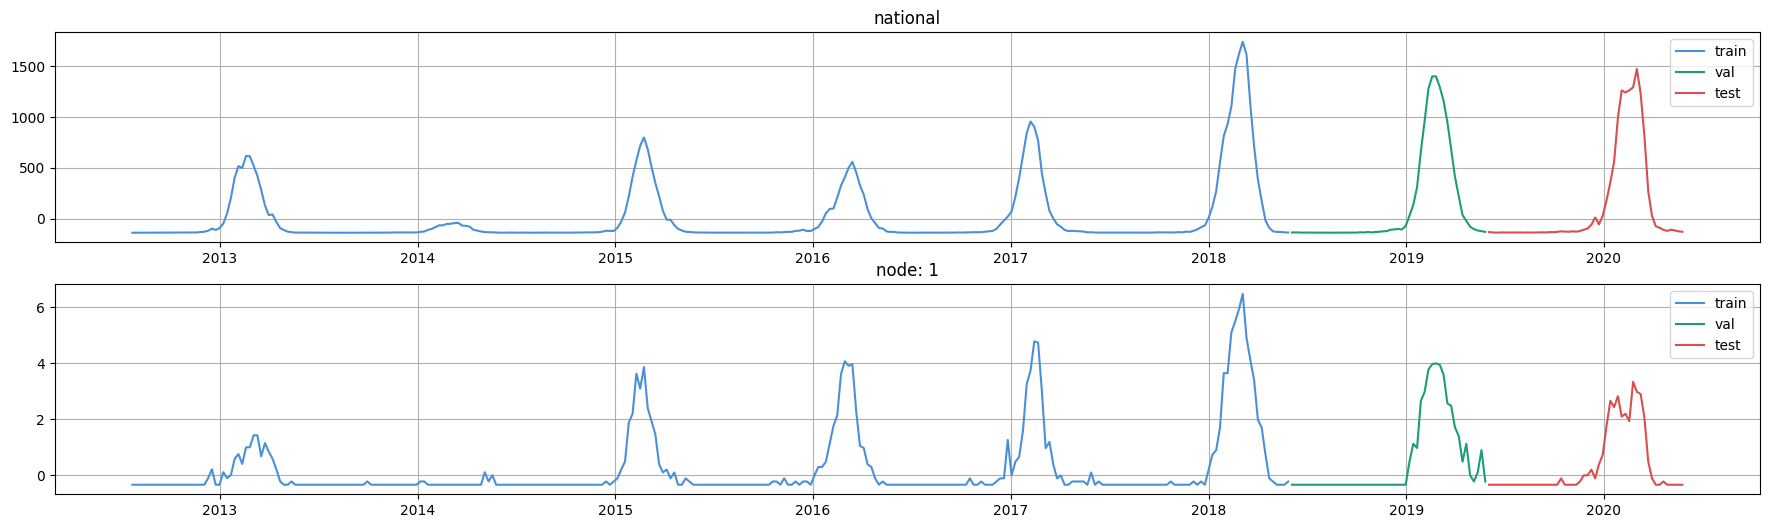

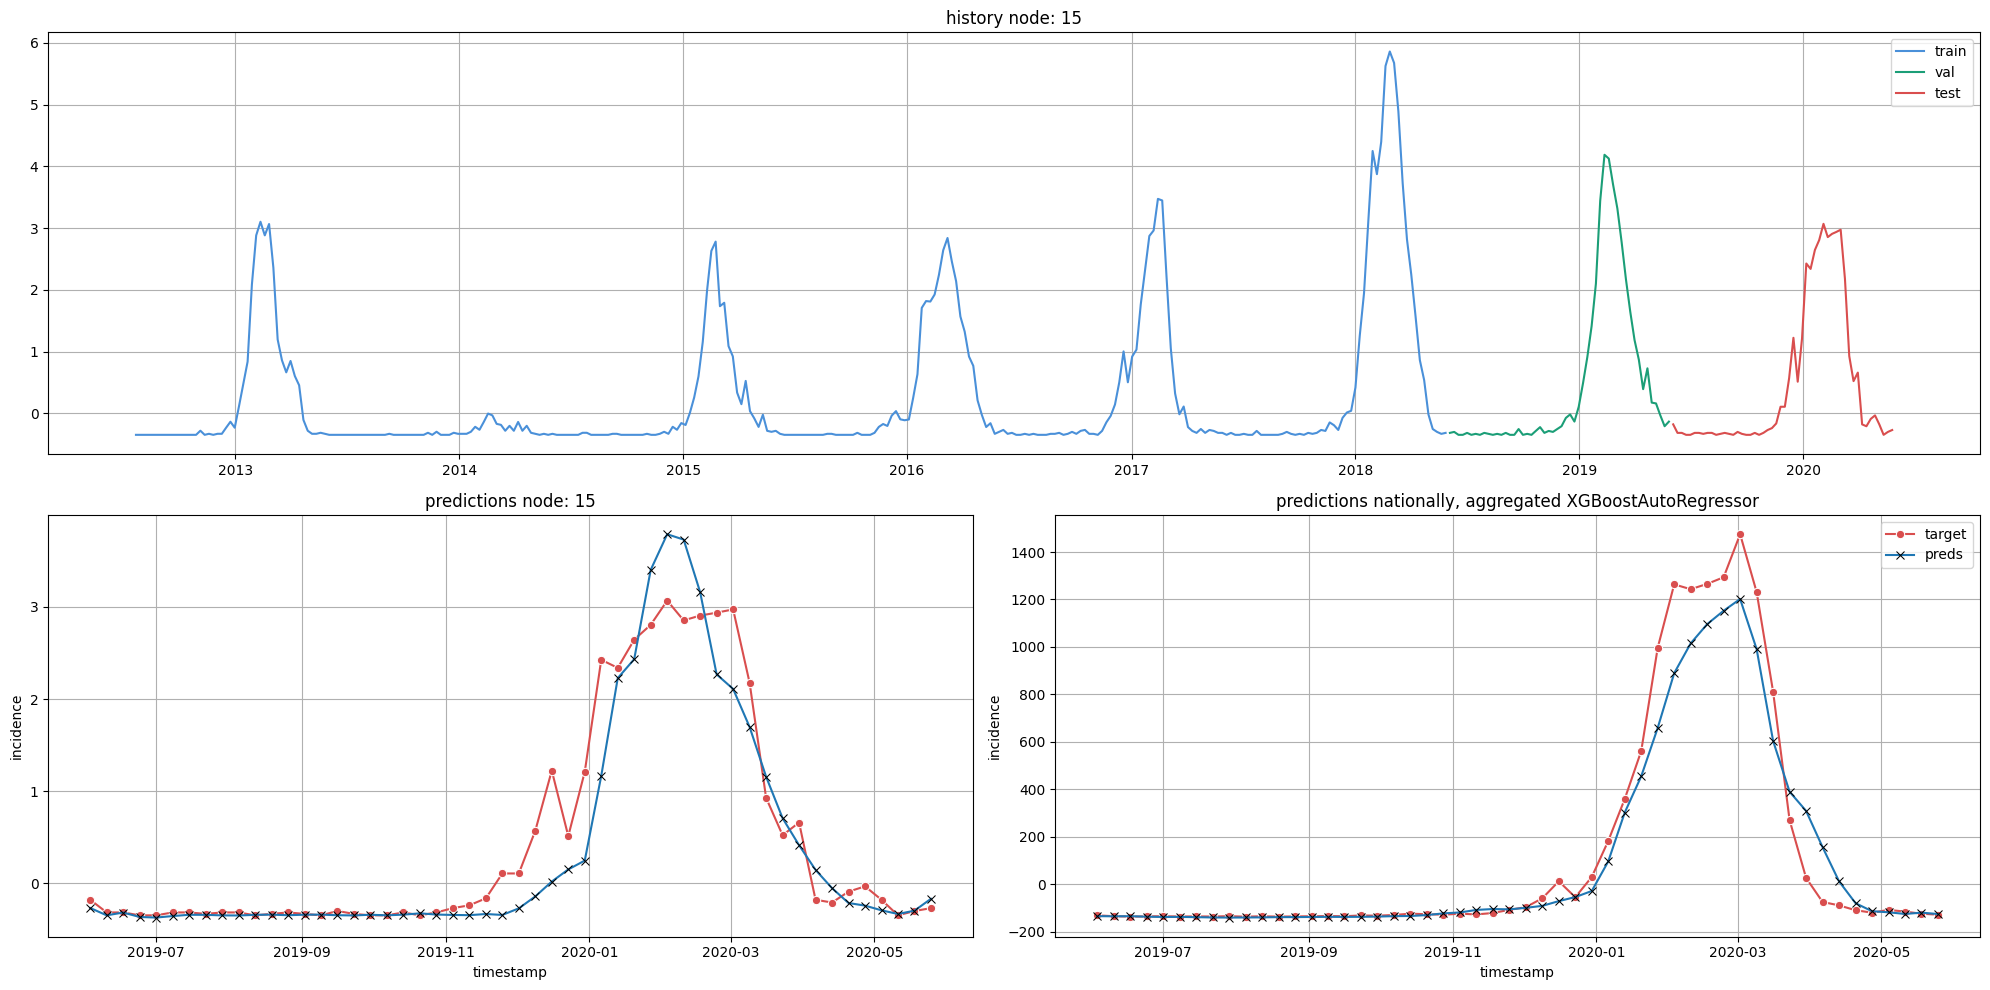

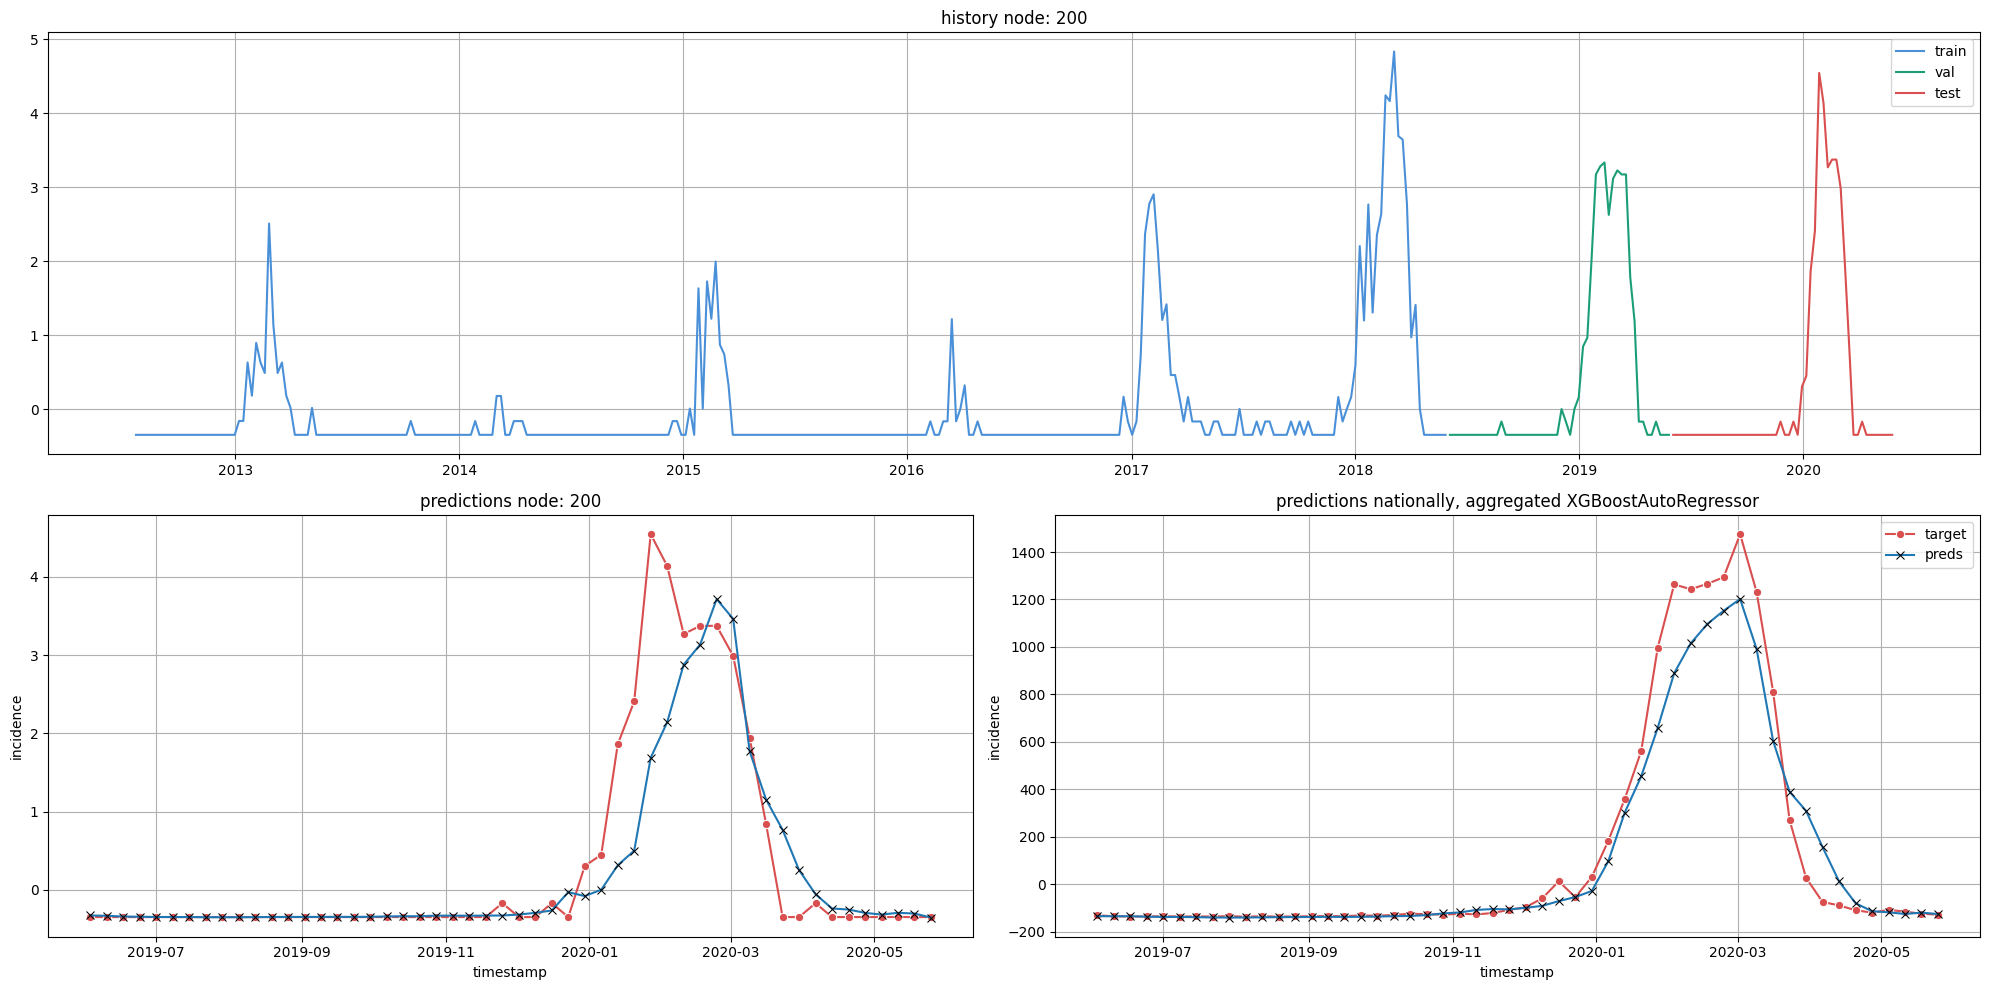

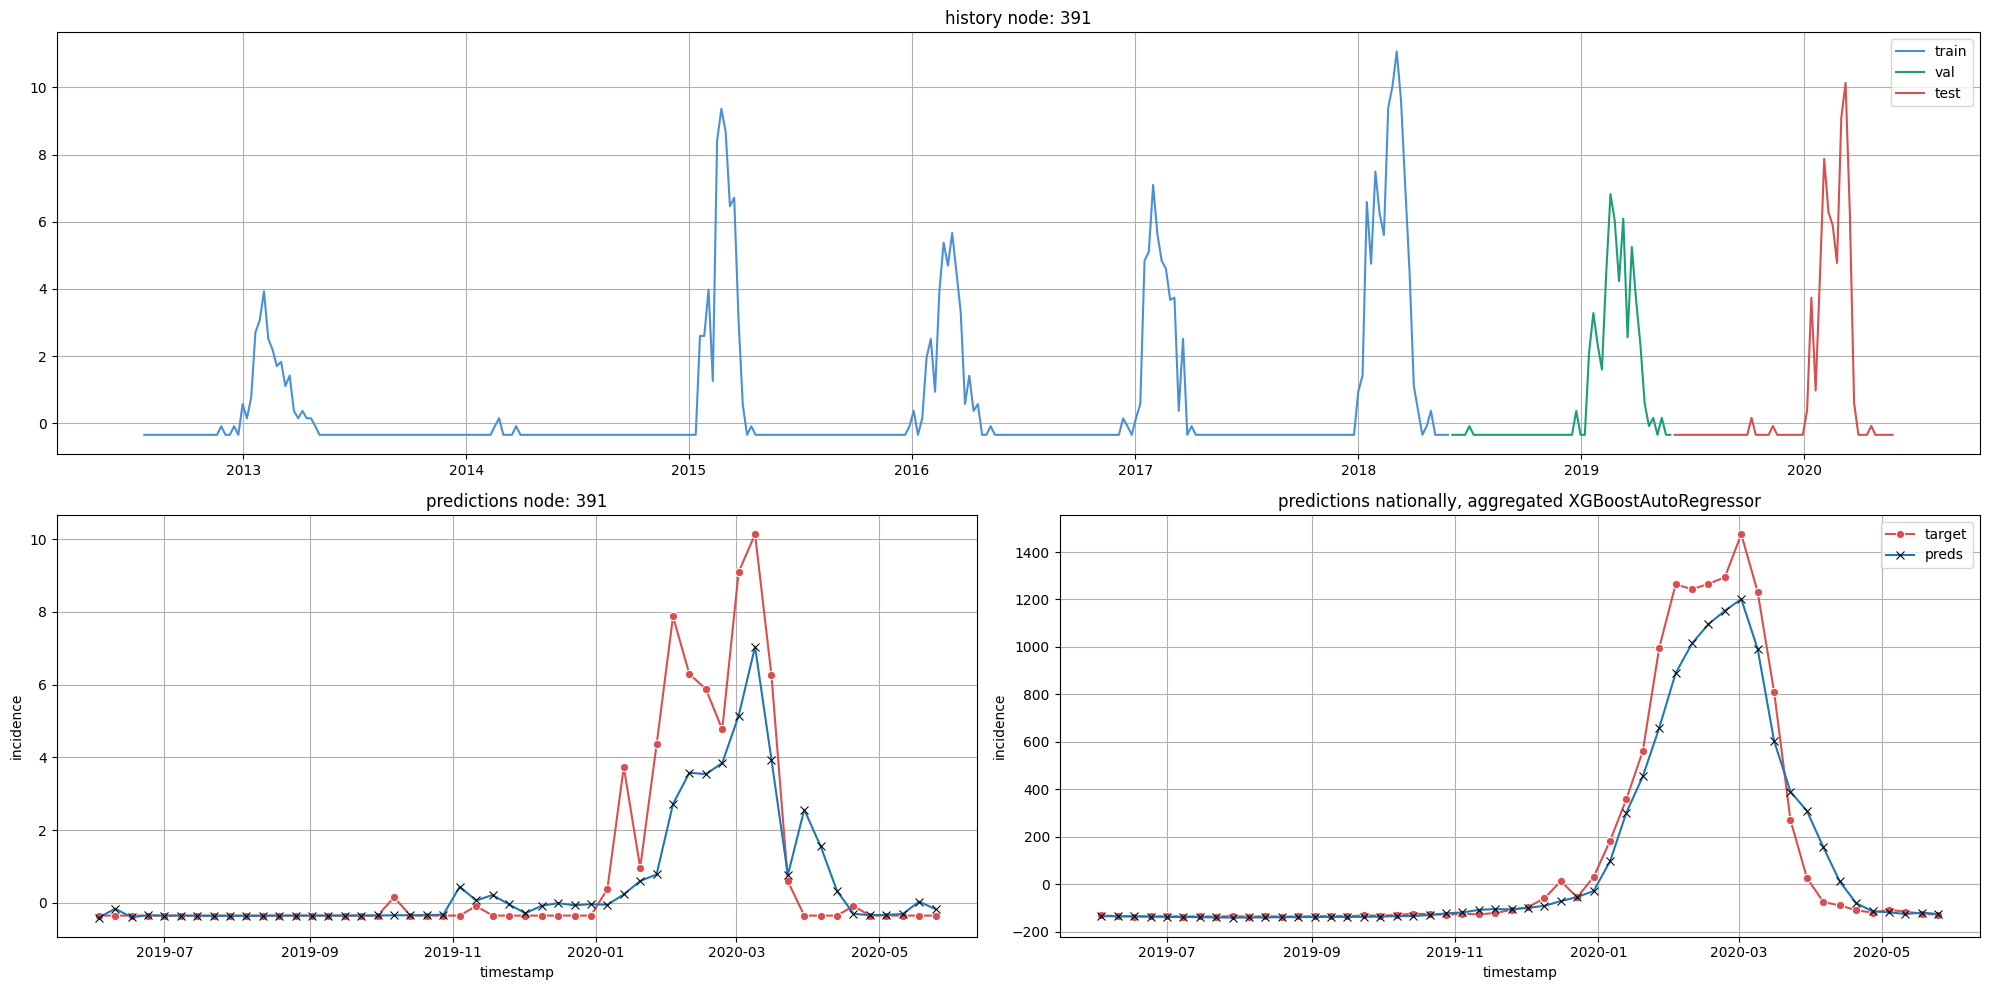

In [10]:
epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(4,8))
epidata.preview()

xgb_model = XGBoostAutoRegressor(epidata)
xgb_model.forecast()
xgb_model.show_forecasts(15)
xgb_model.show_forecasts(200)
xgb_model.show_forecasts(391)